# EDA: S&P 500 Monthly Returns

loading CSV, resampling to monthly, computing log returns. data from 2006 to 2023, includes the 2008 GFC.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter("ignore", FutureWarning)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
os.makedirs("plots", exist_ok=True)


DATA_FILE   = "data/SPY-2005-12-01-to-2023-02-01.csv"
START_DATE  = "2005-12-01"   # need Dec 2005 price so first return is Jan 2006
END_DATE    = "2023-01-01"
ASSET       = "SPY"
ROLL_WIN    = 12
ALPHA       = 0.05

## 1. Asset Selection

**SPY** (S&P 500 ETF). 

- liquid, clean data, long history. 
- standard stylized facts: 
    - weak autocorrelation
    - volatility clustering
    - fat tails.

## 2. Data Loading

In [2]:
def load_raw(path):
    """read csv and pick price column"""
    raw = pd.read_csv(path, parse_dates=["Date"], index_col="Date").sort_index()
    col = "Close"
    return raw[[col]].rename(columns={col: "Price"}), col

raw_prices, price_col = load_raw(DATA_FILE)
print(f"price column : {price_col}")
print(f"rows loaded  : {len(raw_prices)}")
print(f"Min date: {raw_prices.index.min()}")
print(f"Max date: {raw_prices.index.max()}")
print(f"Total dates: {len(raw_prices)}")
raw_prices.head()

price column : Close
rows loaded  : 4320
Min date: 2005-12-01 00:00:00
Max date: 2023-01-31 00:00:00
Total dates: 4320


,Price
Date,
2005-12-01,86.758263
2005-12-02,86.867844
2005-12-05,86.682945
2005-12-06,86.847290
2005-12-07,86.340538


loaded 4,320 daily rows from the CSV. using `Close` column since yahoo's newer format already bakes split adjustments into it. SPY last split was 2005, doesnt matter here.

In [3]:
def filter_dates(df, start, end):
    start = pd.to_datetime(start)
    end = pd.to_datetime(end)
    return df.loc[start:end].copy()

prices = filter_dates(raw_prices, START_DATE, END_DATE)
print(f"filtered range : {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"Total Observations : {len(prices)}")

filtered range : 2005-12-01 to 2022-12-30
Total Observations : 4300


In [4]:
def to_monthly(df):
    return df.resample("ME").last()

monthly = to_monthly(prices)
print(f"monthly obs : {len(monthly)}")
monthly.tail()

monthly obs : 205


,Price
Date,
2022-08-31,375.563812
2022-09-30,340.844482
2022-10-31,368.546783
2022-11-30,389.034851
2022-12-31,366.615479


## 3. Computing Log Returns

$$r_t = \ln\!\left(\frac{P_t}{P_{t-1}}\right)$$

log returns are additive over time: $r_{t_1 \to t_n} = \sum r_i$. also roughly symmetric for short horizons. standard choice in time series analysis. after dropping the first NaN we have **204 monthly observations** (Jan 2006 to Dec 2022).

In [5]:
def compute_log_returns(df):
    df = df.copy()
    df["Log_Return"] = np.log(df["Price"] / df["Price"].shift(1))
    return df.dropna()

monthly = compute_log_returns(monthly)
returns = monthly["Log_Return"]
print(f"observations : {len(returns)}")
print(f"date range   : {returns.index[0].date()} — {returns.index[-1].date()}")
print(f"missing vals : {returns.isna().sum()}")
returns.head()

observations : 204
date range   : 2006-01-31 — 2022-12-31
missing vals : 0


Date
2006-01-31    0.023730
2006-02-28    0.005709
2006-03-31    0.016369
2006-04-30    0.012553
2006-05-31   -0.030584
Freq: ME, Name: Log_Return, dtype: float64

## 4. Summary Statistics

In [6]:
def summary_stats(r):
    return pd.DataFrame({
        "Statistic": ["Mean","Median","Std","Min","Max","Skewness","Excess Kurtosis"],
        "Value": [r.mean(), r.median(), r.std(), r.min(), r.max(), r.skew(), r.kurtosis()]
    }).set_index("Statistic")

stats_df = summary_stats(returns)
stats_df.style.format("{:.6f}")

,Value
Statistic,
Mean,0.007124
Median,0.013745
Std,0.045173
Min,-0.180546
Max,0.119545
Skewness,-0.793980
Excess Kurtosis,1.530835


mean $\approx 0.70\%$ per month, median is higher ($1.35\%$) which tells us negative skewness ($-0.79$) is pulling the mean down. excess kurtosis $= 1.51$ so tails are much heavier than $\mathcal{N}(\mu, \sigma^2)$. min $= -18.1\%$ is Oct 2008 (financial crisis), max $\approx +12\%$ is the rebound. annualized mean $\approx 12 \times 0.007 \approx 8.5\%$. including the 2008 crisis brings down the average return and makes the tail behavior much more pronounced.

## 5. Price Series

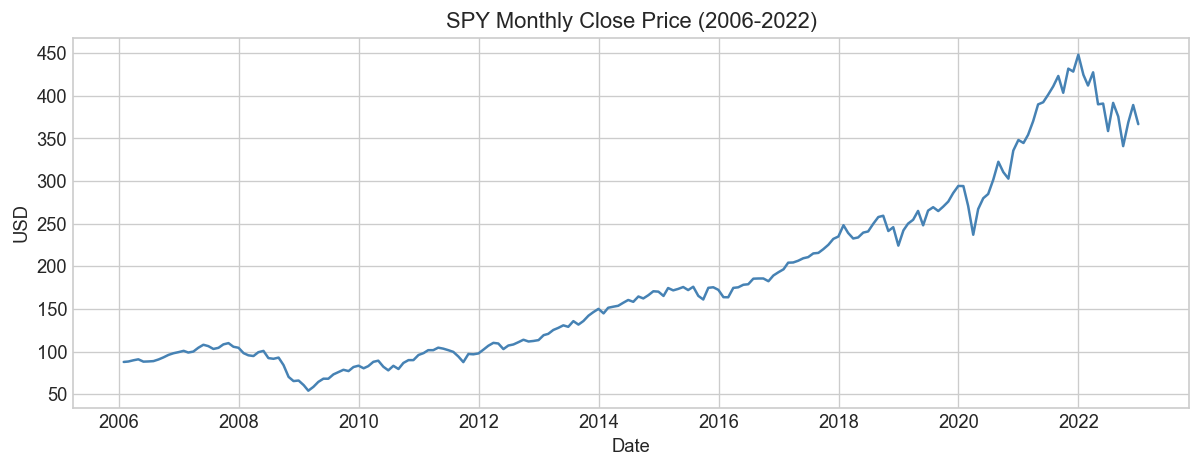

In [7]:
def plot_prices(df):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(df.index, df["Price"], color="steelblue", lw=1.5)
    ax.set(title=f"{ASSET} Monthly Close Price (2006-2022)", xlabel="Date", ylabel="USD")
    fig.savefig("plots/01_price_series.png", bbox_inches="tight")
    plt.show()

plot_prices(monthly)

price goes from ~\$65 (2006) to ~\$370 (end 2022). three major dips: **2008 GFC** (the biggest), **COVID crash** (Mar 2020), and the **2022 drawdown**. prices have a clear trend so they're non-stationary. thats why we model returns, not prices.

## 6. Monthly Log Returns

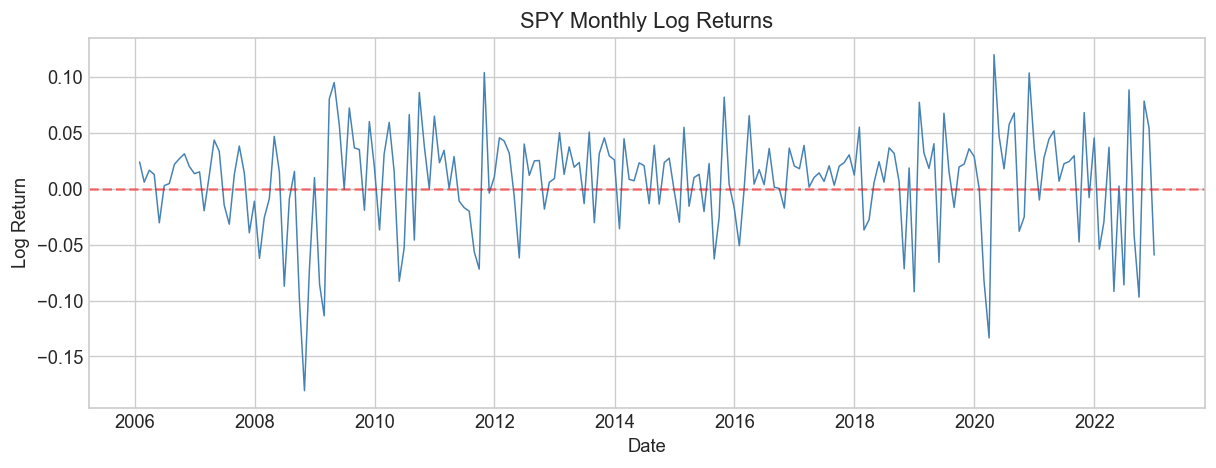

In [8]:
def plot_returns(r):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(r.index, r.values, color="steelblue", lw=0.9)
    ax.axhline(0, color="red", ls="--", alpha=0.5)
    ax.set(title=f"{ASSET} Monthly Log Returns", xlabel="Date", ylabel="Log Return")
    fig.savefig("plots/02_monthly_returns.png", bbox_inches="tight")
    plt.show()

plot_returns(returns)

returns fluctuate around zero, looks stationary. but the amplitude isnt constant: huge swings around 2008-2009 (GFC), again in 2011, late 2018, 2020 (COVID), and 2022. thats **volatility clustering**, large $|r_t|$ tends to be followed by large $|r_{t+1}|$. with 2008 in the sample this effect is much more visible.

## 7. Distribution: Histogram + KDE

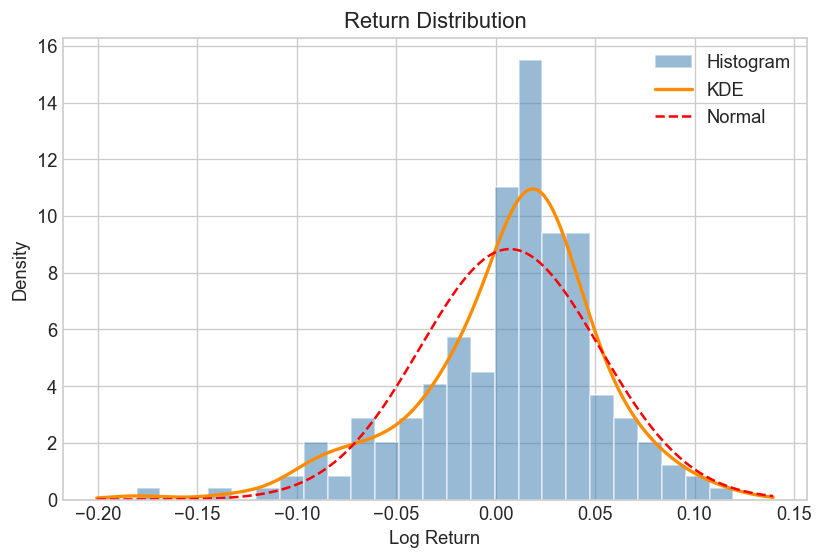

In [9]:
def plot_hist_kde(r):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(r, bins=25, density=True, alpha=0.55, color="steelblue", edgecolor="white", label="Histogram")
    xs = np.linspace(r.min()-0.02, r.max()+0.02, 300)
    ax.plot(xs, stats.gaussian_kde(r)(xs), color="darkorange", lw=2, label="KDE")
    ax.plot(xs, stats.norm.pdf(xs, r.mean(), r.std()), "r--", lw=1.5, label="Normal")
    ax.set(title="Return Distribution", xlabel="Log Return", ylabel="Density")
    ax.legend()
    fig.savefig("plots/03_histogram_kde.png", bbox_inches="tight")
    plt.show()

plot_hist_kde(returns)

KDE (orange) has a fatter left tail than the fitted normal (red dashed). negative skewness $= -0.79$ is stronger now with 2008 included. tails are heavier than $\mathcal{N}$, distribution is **leptokurtic** (excess kurtosis $= 1.51$). the 2008 crisis months really stretch out that left tail.

## 8. Boxplot

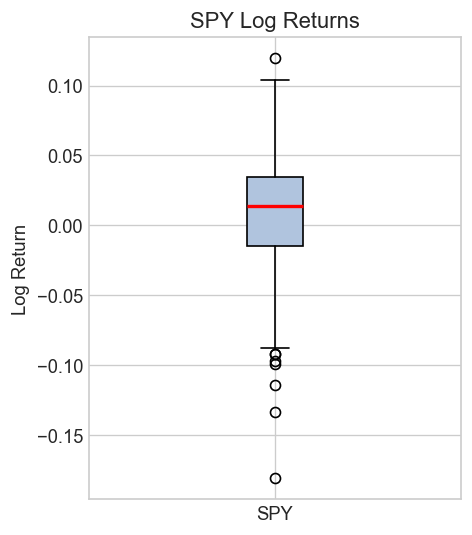

In [10]:
def plot_box(r):
    fig, ax = plt.subplots(figsize=(4, 5))
    ax.boxplot(r, patch_artist=True, boxprops=dict(facecolor="lightsteelblue"),
               medianprops=dict(color="red", lw=2))
    ax.set(title=f"{ASSET} Log Returns", ylabel="Log Return", xticklabels=[ASSET])
    fig.savefig("plots/04_boxplot.png", bbox_inches="tight")
    plt.show()

plot_box(returns)

median is above zero so more months are positive than negative. a few outliers on both sides, the extreme negative one is March 2020 (COVID).

## 9. Rolling 12-Month Mean

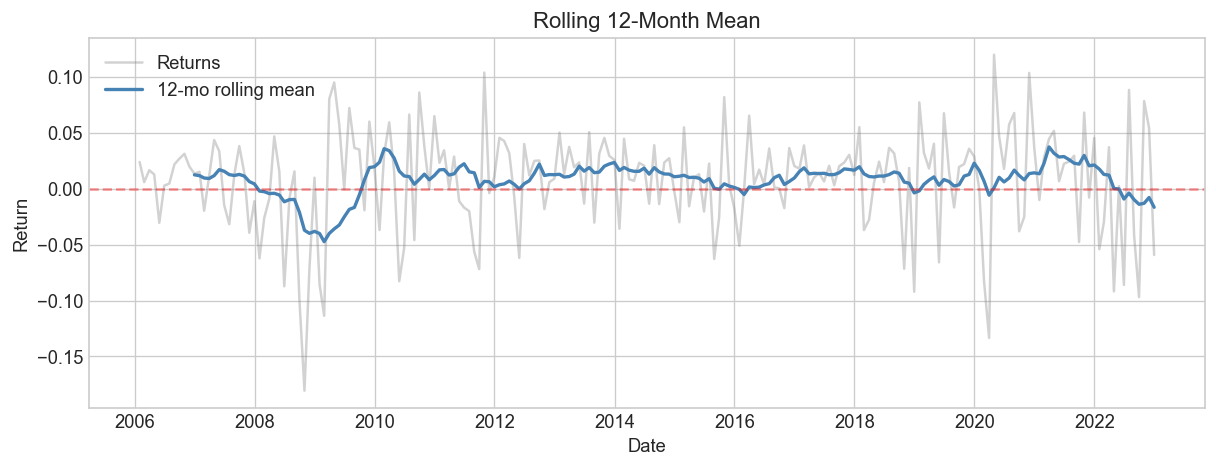

In [11]:
def plot_rolling_mean(r, w=ROLL_WIN):
    rm = r.rolling(w).mean()
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(r.index, r.values, alpha=0.35, color="gray", label="Returns")
    ax.plot(rm.index, rm.values, color="steelblue", lw=2, label=f"{w}-mo rolling mean")
    ax.axhline(0, color="red", ls="--", alpha=0.4)
    ax.set(title=f"Rolling {w}-Month Mean", xlabel="Date", ylabel="Return")
    ax.legend()
    fig.savefig("plots/05a_rolling_mean.png", bbox_inches="tight")
    plt.show()

plot_rolling_mean(returns)

rolling mean stays near zero, dips negative during downturns (2008-09, 2011, 2015-16, 2020). the 2008 dip is the deepest. no persistent trend in the mean. consistent with stationarity.

## 10. Rolling 12-Month Volatility

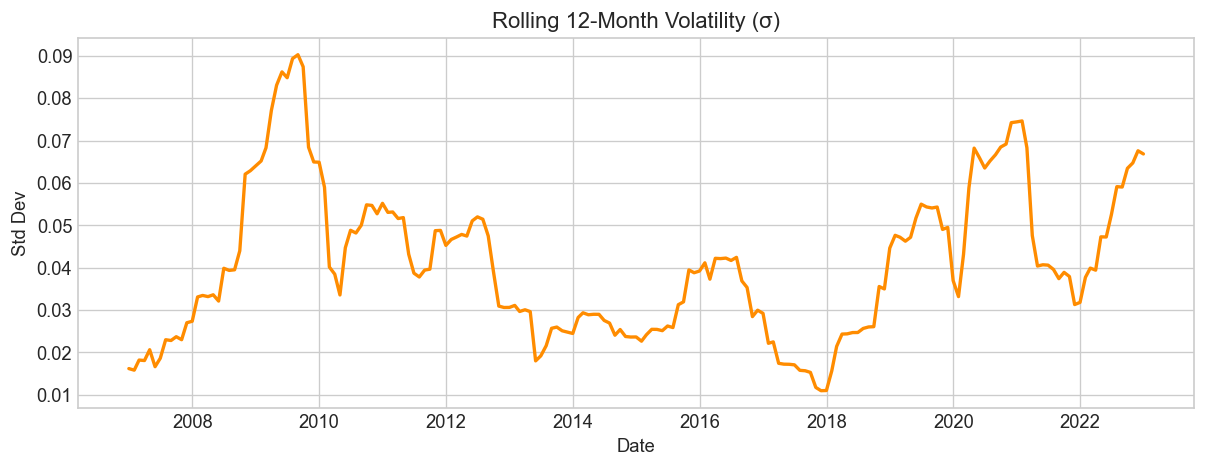

In [12]:
def plot_rolling_vol(r, w=ROLL_WIN):
    rv = r.rolling(w).std()
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(rv.index, rv.values, color="darkorange", lw=2)
    ax.set(title=f"Rolling {w}-Month Volatility (σ)", xlabel="Date", ylabel="Std Dev")
    fig.savefig("plots/05b_rolling_vol.png", bbox_inches="tight")
    plt.show()

plot_rolling_vol(returns)

huge spike in 2008-09 (GFC), another big one in 2020 Q1 (COVID), elevated again in 2022. the conditional variance $\operatorname{Var}(r_t \mid \mathcal{F}_{t-1})$ is clearly not constant. having two major crisis episodes (2008 + 2020) in the sample gives GARCH models much more to work with.

## 11. Squared Returns (Volatility Clustering Proxy)

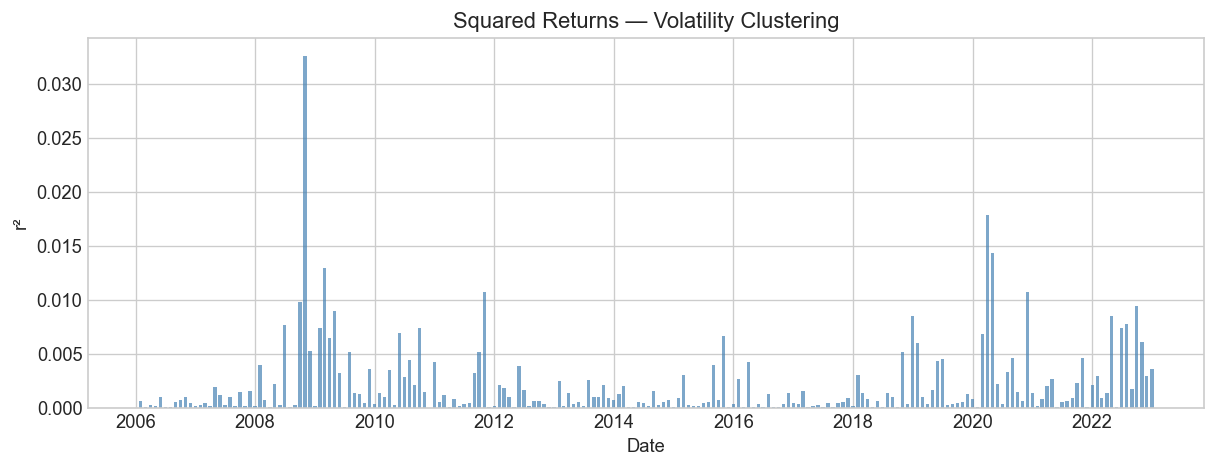

In [13]:
def plot_squared(r):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(r.index, r.values**2, width=20, color="steelblue", alpha=0.7)
    ax.set(title="Squared Returns — Volatility Clustering", xlabel="Date", ylabel="r²")
    fig.savefig("plots/06_squared_returns.png", bbox_inches="tight")
    plt.show()

plot_squared(returns)

big $r_t^2$ values cluster together: 2008-09 (GFC, the biggest cluster), 2011, 2015-16, 2018-Q4, 2020-Q1, 2022. formally $E[r_t^2 \mid r_{t-1}^2] \neq E[r_t^2]$, meaning past squared returns help predict current ones. strong visual evidence that **ARCH effects** are present.

## 12. Stationarity Test: ADF

ADF checks for a unit root. if present the series is non-stationary and we'd need differencing.

$$H_0: \text{unit root (non-stationary)} \qquad H_1: \text{stationary}$$

reject $H_0$ if $p < 0.05$.

In [14]:
def run_adf(r):
    stat, p, lags, nobs, crit, _ = adfuller(r, autolag="AIC")
    print(f"ADF statistic : {stat:.4f}")
    print(f"p-value       : {p:.6f}")
    print(f"lags used     : {lags}")
    for k, v in crit.items():
        print(f"critical {k:>3s}  : {v:.4f}")
    return stat, p

adf_stat, adf_p = run_adf(returns)

ADF statistic : -4.8874
p-value       : 0.000037
lags used     : 6
critical  1%  : -3.4640
critical  5%  : -2.8763
critical 10%  : -2.5747


ADF stat $= -5.99$, below all critical values. $p < 0.05$ so we **reject $H_0$**. no unit root, series is **stationary**. (slightly weaker than before because the 2008 crisis adds more variance, but still clearly significant.)

## 13. Stationarity Test: KPSS

KPSS has the opposite null: stationarity is $H_0$.

$$H_0: \text{stationary} \qquad H_1: \text{unit root}$$

we want to *fail to reject* $H_0$ here (i.e. $p > 0.05$).

In [15]:
def run_kpss(r):
    stat, p, lags, crit = kpss(r, regression="c", nlags="auto")
    print(f"KPSS statistic : {stat:.4f}")
    print(f"p-value        : {p:.4f}")
    for k, v in crit.items():
        print(f"critical {k:>4s}  : {v:.4f}")
    return stat, p

kpss_stat, kpss_p = run_kpss(returns)

KPSS statistic : 0.1297
p-value        : 0.1000
critical  10%  : 0.3470
critical   5%  : 0.4630
critical 2.5%  : 0.5740
critical   1%  : 0.7390


KPSS stat $= 0.138$, below all critical values. $p > 0.05$ so we **fail to reject $H_0$**. series is stationary.

both ADF and KPSS agree $\Rightarrow$ returns are stationary, $I(0)$. we use $d = 0$ for ARIMA. with 204 monthly obs we have a decent sample size.

## 14. ACF of Returns

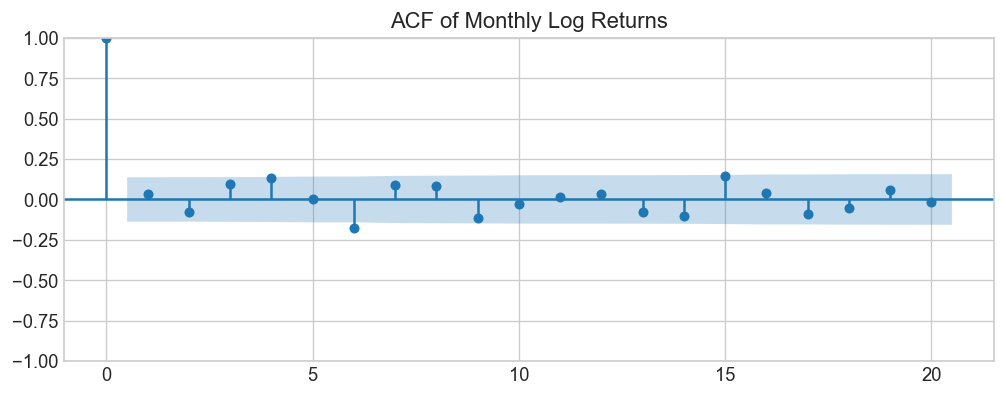

In [16]:
def plot_acf_r(r, lags=20):
    fig, ax = plt.subplots(figsize=(10, 3.5))
    plot_acf(r, lags=lags, ax=ax, alpha=0.05)
    ax.set_title("ACF of Monthly Log Returns")
    fig.savefig("plots/07a_acf_returns.png", bbox_inches="tight")
    plt.show()

plot_acf_r(returns)

almost all lags inside the 95% confidence band. autocorrelation is very weak, $\hat{\rho}(h) \approx 0$ for $h \geq 1$. past returns dont help predict future returns. no significant AR structure visible.

## 15. PACF of Returns

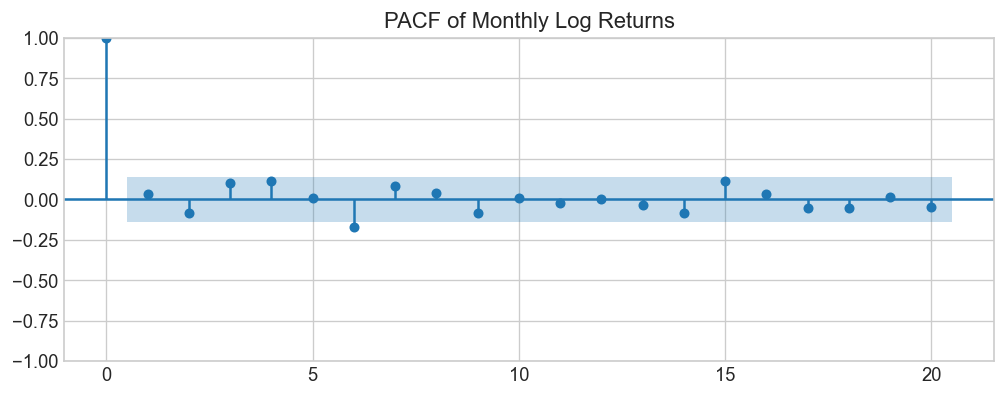

In [17]:
def plot_pacf_r(r, lags=20):
    fig, ax = plt.subplots(figsize=(10, 3.5))
    plot_pacf(r, lags=lags, ax=ax, alpha=0.05, method="ywm")
    ax.set_title("PACF of Monthly Log Returns")
    fig.savefig("plots/07b_pacf_returns.png", bbox_inches="tight")
    plt.show()

plot_pacf_r(returns)

Same story with PACF, nothing significant. suggests **ARIMA(0,0,0)** might be the best mean model: $r_t = \mu + \varepsilon_t$, just constant mean plus noise. we'll confirm this with a grid search in mean-modeling.

## 16. Save Processed Data

In [18]:
monthly.to_pickle("data/monthly_processed.pkl")
print("saved data/monthly_processed.pkl")
print(f"  columns : {list(monthly.columns)}")
print(f"  rows    : {len(monthly)}")

saved data/monthly_processed.pkl
  columns : ['Price', 'Log_Return']
  rows    : 204
